# Solute transport: mPCN vs pCN convergence

Generate a new solute-transport dataset (shared draws) and compare 10 mPCN chains (P=100, rho=0.9) against 10 of 100 independent pCN chains with random prior starts.
All chains are cached under estimations/ and reused if present.

In [1]:
import os
import sys
from pathlib import Path
import json
import hashlib
import time

import numpy as np
import matplotlib.pyplot as plt

def _resolve_repo_root():
    env_root = os.environ.get("MULTIPROPOSAL_RUN_ROOT")
    if env_root:
        return Path(env_root).expanduser().resolve()
    root = Path.cwd().resolve()
    while root != root.parent and not (root / "pyproject.toml").exists():
        root = root.parent
    return root

repo_root = _resolve_repo_root()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
src_path = repo_root / "src"
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from multiproposal.problems.advection_diffusion import (
    make_omegas_power,
    make_Astar_nn,
    make_Astar_from_atrue,
    params_from_skew,
    prior_diag_from_powerlaw,
    solve_theta,
 )
from multiproposal.problems.advection_diffusion import AdvectionDiffusionToy
from multiproposal.algorithms.mpcn import mpcn_chain
from multiproposal.algorithms.pcn import pcn_chain
from multiproposal.utils.run_paths import format_float_tag
from multiproposal.plotting.figure_style import apply_pub_style

In [2]:
# Solute transport configuration
seed_data = 0
seed_mcmc = 202

use_big_config = True
if use_big_config:
    d = 40
    obs_highest_freq = 12
    obs_bandwidth = 7
else:
    d = 20
    obs_highest_freq = 8
    obs_bandwidth = 5

kappa = 0.02
sigma = 0.5
alpha = 3.0
gamma = 2.0
tau2 = 2.0
a_mode = 'nearest_neighbor'
use_prior_A = True
shared_draws_seed = seed_data
obs_config = 'central_modes'

print('d:', d)
print('kappa:', kappa)
print('sigma:', sigma)
print('obs_config:', obs_config)

d: 40
kappa: 0.02
sigma: 0.5
obs_config: central_modes


In [3]:
# Configuration is defined in the previous cell.
pass

In [4]:
if isinstance(obs_config, dict):
    obs_config_serializable = {
        key: (val.tolist() if isinstance(val, np.ndarray) else val)
        for key, val in obs_config.items()
    }
else:
    obs_config_serializable = obs_config

data_id_config = {
    'seed_data': seed_data,
    'kappa': kappa,
    'sigma': sigma,
    'alpha': alpha,
    'gamma': gamma,
    'tau2': tau2,
    'a_mode': a_mode,
    'use_prior_A': use_prior_A,
    'shared_draws_seed': shared_draws_seed,
    'obs_highest_freq': obs_highest_freq,
    'obs_bandwidth': obs_bandwidth,
    'obs_config': obs_config_serializable,
    'd': d,
}
data_config = dict(data_id_config)

In [5]:
def _canonicalize_payload(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, dict):
        return {key: _canonicalize_payload(val) for key, val in sorted(obj.items())}
    if isinstance(obj, (list, tuple)):
        return [_canonicalize_payload(val) for val in obj]
    return obj

def _stable_hash(payload, length=12):
    data = json.dumps(
        _canonicalize_payload(payload),
        sort_keys=True,
        separators=(",", ":"),
        ensure_ascii=True,
    ).encode("utf-8")
    return hashlib.sha256(data).hexdigest()[:length]

In [6]:
# Shared-draws helpers
def get_obs_indices(dim_value, highest_freq, bandwidth):
    highest_freq = min(highest_freq, dim_value)
    bandwidth = min(bandwidth, dim_value)
    start = max(0, highest_freq - bandwidth + 1)
    return np.arange(start, highest_freq + 1, dtype=int)

def get_param_indices_for_dim(dim, shared_draws):
    cache = shared_draws.setdefault('param_indices_cache', {})
    if dim not in cache:
        iju = shared_draws['param_iju']
        mask = (iju[0] < dim) & (iju[1] < dim)
        cache[dim] = np.nonzero(mask)[0]
    return cache[dim]

def build_shared_draws(
    d_max,
    kappa,
    sigma,
    alpha,
    gamma,
    tau2,
    offset,
    a_mode,
    seed,
):
    rng = np.random.default_rng(seed)
    m_max = d_max * (d_max - 1) // 2
    prior_diag_max = prior_diag_from_powerlaw(
        d_max, alpha=alpha, gamma=gamma, tau2=tau2, offset=offset
    )
    if prior_diag_max.shape != (m_max,):
        raise ValueError(
            f'prior_diag_max must have shape ({m_max},), got {prior_diag_max.shape}'
        )
    if a_mode == 'nearest_neighbor':
        omegas = make_omegas_power(
            d_max, beta=alpha, c=2.0 ** (-gamma), offset=offset
        )
        A_true_max = make_Astar_nn(d_max, omegas)
        a_true_max = params_from_skew(A_true_max)
    elif a_mode == 'prior':
        z_prior = rng.standard_normal(m_max)
        a_true_max = z_prior * np.sqrt(prior_diag_max)
        A_true_max = make_Astar_from_atrue(d_max, a_true_max)
    else:
        raise ValueError("a_mode must be 'nearest_neighbor' or 'prior'")
    g_max = np.zeros(d_max, dtype=float)
    g_max[0] = 1.0
    theta_true_max = solve_theta(d_max, a_true_max, g_max, kappa)
    noise_max = rng.standard_normal(d_max)
    z_init = rng.standard_normal(m_max)
    a_init_max = z_init * np.sqrt(prior_diag_max)
    return {
        'd_max': d_max,
        'm_max': m_max,
        'kappa': kappa,
        'sigma': sigma,
        'alpha': alpha,
        'gamma': gamma,
        'tau2': tau2,
        'offset': offset,
        'a_mode': a_mode,
        'param_iju': np.triu_indices(d_max, k=1),
        'param_indices_cache': {},
        'prior_diag': prior_diag_max,
        'a_true': a_true_max,
        'A_true': A_true_max,
        'g': g_max,
        'theta_true': theta_true_max,
        'noise': noise_max,
        'a_init': a_init_max,
    }

def generate_advection_diffusion_data_shared(dim, obs_indices, shared_draws):
    a_mode_local = shared_draws['a_mode']
    param_idx = get_param_indices_for_dim(dim, shared_draws)
    prior_diag = shared_draws['prior_diag'][param_idx]
    g = shared_draws['g'][:dim]
    if a_mode_local == 'nearest_neighbor':
        omegas = make_omegas_power(
            dim,
            beta=shared_draws['alpha'],
            c=2.0 ** (-shared_draws['gamma']),
            offset=shared_draws['offset'],
        )
        A_true = make_Astar_nn(dim, omegas)
        a_true = params_from_skew(A_true)
        theta_true = solve_theta(dim, a_true, g, shared_draws['kappa'])
    elif a_mode_local == 'prior':
        a_true = shared_draws['a_true'][param_idx]
        A_true = make_Astar_from_atrue(dim, a_true)
        theta_true = shared_draws['theta_true'][:dim]
    else:
        raise ValueError("a_mode must be 'nearest_neighbor' or 'prior'")
    noise = shared_draws['noise'][:dim]
    y = theta_true[obs_indices] + shared_draws['sigma'] * noise[obs_indices]
    a_init = shared_draws['a_init'][param_idx]
    return {
        'dim': dim,
        'kappa': shared_draws['kappa'],
        'alpha': shared_draws['alpha'],
        'gamma': shared_draws['gamma'],
        'tau2': shared_draws['tau2'],
        'sigma': shared_draws['sigma'],
        'obs_indices': obs_indices,
        'prior_diag': prior_diag,
        'a_true': a_true,
        'A_true': A_true,
        'g': g,
        'theta_true': theta_true,
        'y': y,
        'a_init': a_init,
    }

def build_problem_for_dim(dim, shared_draws):
    obs_indices = get_obs_indices(dim, obs_highest_freq, obs_bandwidth)
    data = generate_advection_diffusion_data_shared(dim, obs_indices, shared_draws)
    problem = AdvectionDiffusionToy(
        dim=dim,
        kappa=kappa,
        sigma=sigma,
        y=data['y'],
        obs_indices=obs_indices,
        g=data['g'],
        prior_diag=data['prior_diag'],
    )
    return problem, data['a_init'], data

In [7]:
shared_draws = build_shared_draws(
    d_max=d,
    kappa=kappa,
    sigma=sigma,
    alpha=alpha,
    gamma=gamma,
    tau2=tau2,
    offset=1.0,
    a_mode='prior' if use_prior_A else a_mode,
    seed=shared_draws_seed,
)
problem, a_init, data = build_problem_for_dim(d, shared_draws)
prior_diag = data['prior_diag']

print('Shared draws ready with d:', d)
print('Parameter dim:', problem.dim)
print('Initial x0 norm:', np.linalg.norm(a_init))

Shared draws ready with d: 40
Parameter dim: 780
Initial x0 norm: 0.33344310180534587


In [8]:
# MCMC configuration
n_iters = 1000
rho = 0.9
P = 100
num_pcn_chains = 100
num_mpcn_chains = 30
burn_in = 0

load_only = False

print('n_iters:', n_iters)
print('rho:', rho)
print('P:', P)
print('num_pcn_chains:', num_pcn_chains)
print('num_mpcn_chains:', num_mpcn_chains)
print('load_only:', load_only)

n_iters: 1000
rho: 0.9
P: 100
num_pcn_chains: 100
num_mpcn_chains: 30
load_only: False


In [9]:
run_config = {
    'dataset': 'solute_transport',
    'algorithm': 'mpcn_pcn_convergence',
    'data': data_config,
    'algorithm_config': {
        'n_iters': n_iters,
        'rho': rho,
        'P': P,
        'num_pcn_chains': num_pcn_chains,
        'num_mpcn_chains': num_mpcn_chains,
        'seed_mcmc': seed_mcmc,
    },
}
data_id_override = "data_h4afe80f670cc"
run_id_override = "mpcn_pcn_convergence_hf7e75042285f"

data_id = data_id_override or f"data_h{_stable_hash(data_id_config)}"
run_id = run_id_override or f"mpcn_pcn_convergence_seed{seed_mcmc}"

estimations_dir = repo_root / 'estimations' / 'solute_transport' / data_id / 'fixed' / run_id
reports_dir = repo_root / 'reports' / 'solute_transport' / data_id / 'fixed' / run_id
estimations_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

config_path = estimations_dir / 'config.json'
if not config_path.exists():
    payload = dict(run_config)
    payload['data_id'] = data_id
    payload['run_id'] = run_id
    with open(config_path, 'w', encoding='utf-8') as handle:
        json.dump(payload, handle, indent=2)

print('data_id:', data_id)
print('run_id:', run_id)
print('Run directory:', estimations_dir)

data_id: data_h4afe80f670cc
run_id: mpcn_pcn_convergence_hf7e75042285f
Run directory: /Users/guillers/Documents/GitHub/multiproposal-internal/estimations/solute_transport/data_h4afe80f670cc/fixed/mpcn_pcn_convergence_hf7e75042285f


In [10]:
rho_tag = format_float_tag(rho)
pcn_chains_dir = estimations_dir / 'chains' / 'independent_chains'
mpcn_chains_dir = estimations_dir / 'chains' / 'mpcn_independent'
pcn_chains_dir.mkdir(parents=True, exist_ok=True)
mpcn_chains_dir.mkdir(parents=True, exist_ok=True)

def pcn_chain_path(chain_idx):
    return pcn_chains_dir / f'pcn_independent_rho{rho_tag}_seed{seed_mcmc}_chain{chain_idx:03d}.npz'

def pcn_index_path():
    return pcn_chains_dir / f'pcn_independent_rho{rho_tag}_seed{seed_mcmc}_index.json'

def mpcn_chain_path(chain_idx, seed):
    return mpcn_chains_dir / f'mpcn_P{P}_rho{rho_tag}_seed{seed}_chain{chain_idx:03d}.npz'

def mpcn_index_path():
    return mpcn_chains_dir / f'mpcn_P{P}_rho{rho_tag}_seed{seed_mcmc}_index.json'

def save_index(path, payload):
    with open(path, 'w', encoding='utf-8') as handle:
        json.dump(payload, handle, indent=2)

def load_index(path, expected_meta=None):
    if not path.exists():
        return None
    with open(path, 'r', encoding='utf-8') as handle:
        payload = json.load(handle)
    if expected_meta is None:
        return payload
    meta = payload.get('metadata', {})
    for key, value in expected_meta.items():
        if meta.get(key) != value:
            return None
    return payload

def save_chain(path, chain, accept_rate, runtime_sec, extra=None):
    payload = {
        'chain': chain,
        'accept_rate': np.nan if accept_rate is None else float(accept_rate),
        'runtime_sec': float(runtime_sec),
    }
    if extra:
        payload.update(extra)
    np.savez_compressed(path, **payload)

def load_chain(path):
    if not path.exists():
        return None
    data = np.load(path, allow_pickle=True)
    chain = data['chain']
    accept_rate = float(data['accept_rate']) if 'accept_rate' in data else np.nan
    if np.isnan(accept_rate):
        accept_rate = None
    runtime_sec = float(data['runtime_sec']) if 'runtime_sec' in data else 0.0
    return chain, accept_rate, runtime_sec

In [11]:
def sample_prior_points(rng, prior_diag, count):
    z = rng.standard_normal((count, prior_diag.shape[0]))
    return z * np.sqrt(prior_diag)[None, :]

rng_starts = np.random.default_rng(seed_mcmc)
pcn_start_points = sample_prior_points(rng_starts, prior_diag, num_pcn_chains)

rng_select = np.random.default_rng(seed_mcmc + 1)
mpcn_start_indices = rng_select.choice(num_pcn_chains, size=num_mpcn_chains, replace=False)
mpcn_start_points = pcn_start_points[mpcn_start_indices]

print('Selected mPCN start indices:', mpcn_start_indices)

Selected mPCN start indices: [69 62 31 20 71 73 56 17 72 95 70 37 79  6  3 42 93 89 86 34 75 98 11 25
 22 48 51 18 83 68]


In [12]:
pcn_expected_meta = {
    'rho': float(rho),
    'seed_mcmc': int(seed_mcmc),
    'n_iters': int(n_iters),
    'count': int(num_pcn_chains),
    'data_id': data_id,
    'run_id': run_id,
}
pcn_index_payload = load_index(pcn_index_path(), expected_meta=pcn_expected_meta)
pcn_chains = []
pcn_accept_rates = []
pcn_runtimes = []

if pcn_index_payload is None:
    pcn_index_payload = {
        'metadata': dict(pcn_expected_meta),
        'chains': [],
    }

for chain_idx in range(num_pcn_chains):
    chain_path = pcn_chain_path(chain_idx)
    loaded = load_chain(chain_path)
    if loaded is None:
        if load_only:
            raise FileNotFoundError(f'Missing pCN chain: {chain_path}')
        rng = np.random.default_rng(seed_mcmc + 2000 + chain_idx)
        t0 = time.perf_counter()
        chain, acc_rate = pcn_chain(
            pcn_start_points[chain_idx],
            problem,
            rng,
            n_iters,
            rho=rho,
            return_acceptance=True,
        )
        runtime_sec = time.perf_counter() - t0
        save_chain(
            chain_path,
            chain,
            acc_rate,
            runtime_sec,
            extra={'start_index': int(chain_idx)},
        )
        loaded = (chain, acc_rate, runtime_sec)
    chain, acc_rate, runtime_sec = loaded
    pcn_chains.append(chain)
    pcn_accept_rates.append(acc_rate)
    pcn_runtimes.append(runtime_sec)

pcn_index_payload['chains'] = [
    {
        'chain_idx': int(i),
        'file': pcn_chain_path(i).name,
        'seed': int(seed_mcmc + 2000 + i),
        'start_index': int(i),
    }
    for i in range(num_pcn_chains)
 ]
save_index(pcn_index_path(), pcn_index_payload)

print('Loaded pCN chains:', len(pcn_chains))

Loaded pCN chains: 100


In [13]:
mpcn_expected_meta = {
    'rho': float(rho),
    'P': int(P),
    'seed_mcmc': int(seed_mcmc),
    'n_iters': int(n_iters),
    'count': int(num_mpcn_chains),
    'data_id': data_id,
    'run_id': run_id,
}
mpcn_index_payload = load_index(mpcn_index_path(), expected_meta=mpcn_expected_meta)
mpcn_chains = []
mpcn_accept_rates = []
mpcn_runtimes = []

if mpcn_index_payload is None:
    mpcn_index_payload = {
        'metadata': dict(mpcn_expected_meta),
        'chains': [],
    }

for chain_idx, start_idx in enumerate(mpcn_start_indices):
    seed = seed_mcmc + 5000 + chain_idx
    chain_path = mpcn_chain_path(chain_idx, seed)
    loaded = load_chain(chain_path)
    if loaded is None:
        if load_only:
            raise FileNotFoundError(f'Missing mPCN chain: {chain_path}')
        rng = np.random.default_rng(seed)
        t0 = time.perf_counter()
        chain, accepted_index = mpcn_chain(
            mpcn_start_points[chain_idx],
            problem,
            rng,
            n_iters,
            rho=rho,
            n_props=P,
            return_indices=True,
            n_jobs=1,
            parallel_backend='auto',
            parallelize_props=False,
            llh_chunk_size=0,
        )
        runtime_sec = time.perf_counter() - t0
        acc_rate = float(np.mean(accepted_index != 0))
        save_chain(
            chain_path,
            chain,
            acc_rate,
            runtime_sec,
            extra={'start_index': int(start_idx)},
        )
        loaded = (chain, acc_rate, runtime_sec)
    chain, acc_rate, runtime_sec = loaded
    mpcn_chains.append(chain)
    mpcn_accept_rates.append(acc_rate)
    mpcn_runtimes.append(runtime_sec)

mpcn_index_payload['chains'] = [
    {
        'chain_idx': int(i),
        'file': mpcn_chain_path(i, seed_mcmc + 5000 + i).name,
        'seed': int(seed_mcmc + 5000 + i),
        'start_index': int(mpcn_start_indices[i]),
    }
    for i in range(num_mpcn_chains)
 ]
save_index(mpcn_index_path(), mpcn_index_payload)

print('Loaded mPCN chains:', len(mpcn_chains))

Loaded mPCN chains: 30


In [14]:
# Traceplots: mPCN (top) vs pCN (bottom) for first 3 parameters
apply_pub_style()

comp_list = [0, 1, 2]
comp_list = [idx for idx in comp_list if idx < problem.dim]
if len(comp_list) < 1:
    raise ValueError('Need at least one component for traceplots.')

plot_n = min(n_iters, 1000)
mpcn_plot_count = 30
pcn_plot_count = 100
row_height = 1.0

mpcn_plot_count = min(mpcn_plot_count, len(mpcn_chains))
pcn_plot_count = min(pcn_plot_count, len(pcn_chains))

mpcn_plot_indices = list(range(mpcn_plot_count))
pcn_pick_indices = list(mpcn_start_indices)[:pcn_plot_count]
if len(pcn_pick_indices) < pcn_plot_count:
    pcn_pick_indices = list(range(pcn_plot_count))

trace_series = []
for i in mpcn_plot_indices:
    trace_series.append((f'mPCN chain {i + 1}', mpcn_chains[i]))
for pcn_idx in pcn_pick_indices:
    trace_series.append((f'pCN chain {pcn_idx + 1}', pcn_chains[pcn_idx]))

true_values = data.get('a_true', None)

nrows = len(trace_series)
ncols = len(comp_list)
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4.2 * ncols, row_height * nrows),
    sharex=True,
    sharey='col',
)
if nrows == 1:
    axes = np.array([axes])
if ncols == 1:
    axes = axes[:, None]

for row_idx, (label, chain) in enumerate(trace_series):
    post_chain = chain[:plot_n]
    for col_idx, comp in enumerate(comp_list):
        ax = axes[row_idx, col_idx]
        ax.plot(post_chain[:, comp], linewidth=0.6, color='tab:blue')
        if true_values is not None:
            ax.axhline(
                true_values[comp],
                color='black',
                linestyle=':',
                linewidth=0.8,
            )
        if row_idx == 0:
            ax.set_title(f'Component {comp}')
        if col_idx == 0:
            ax.set_ylabel(label, rotation=0, labelpad=40, va='center')
        ax.grid(alpha=0.2)

for ax in axes[-1, :]:
    ax.set_xlabel('Iteration')

fig.suptitle('Traceplots: mPCN (top) vs pCN (bottom)')
fig.tight_layout()
fig.savefig(
    reports_dir / f'solute_transport_mpcn_vs_pcn_traceplots_rho{rho_tag}.png',
    bbox_inches='tight',
)
plt.show()

KeyboardInterrupt: 

: 

: 

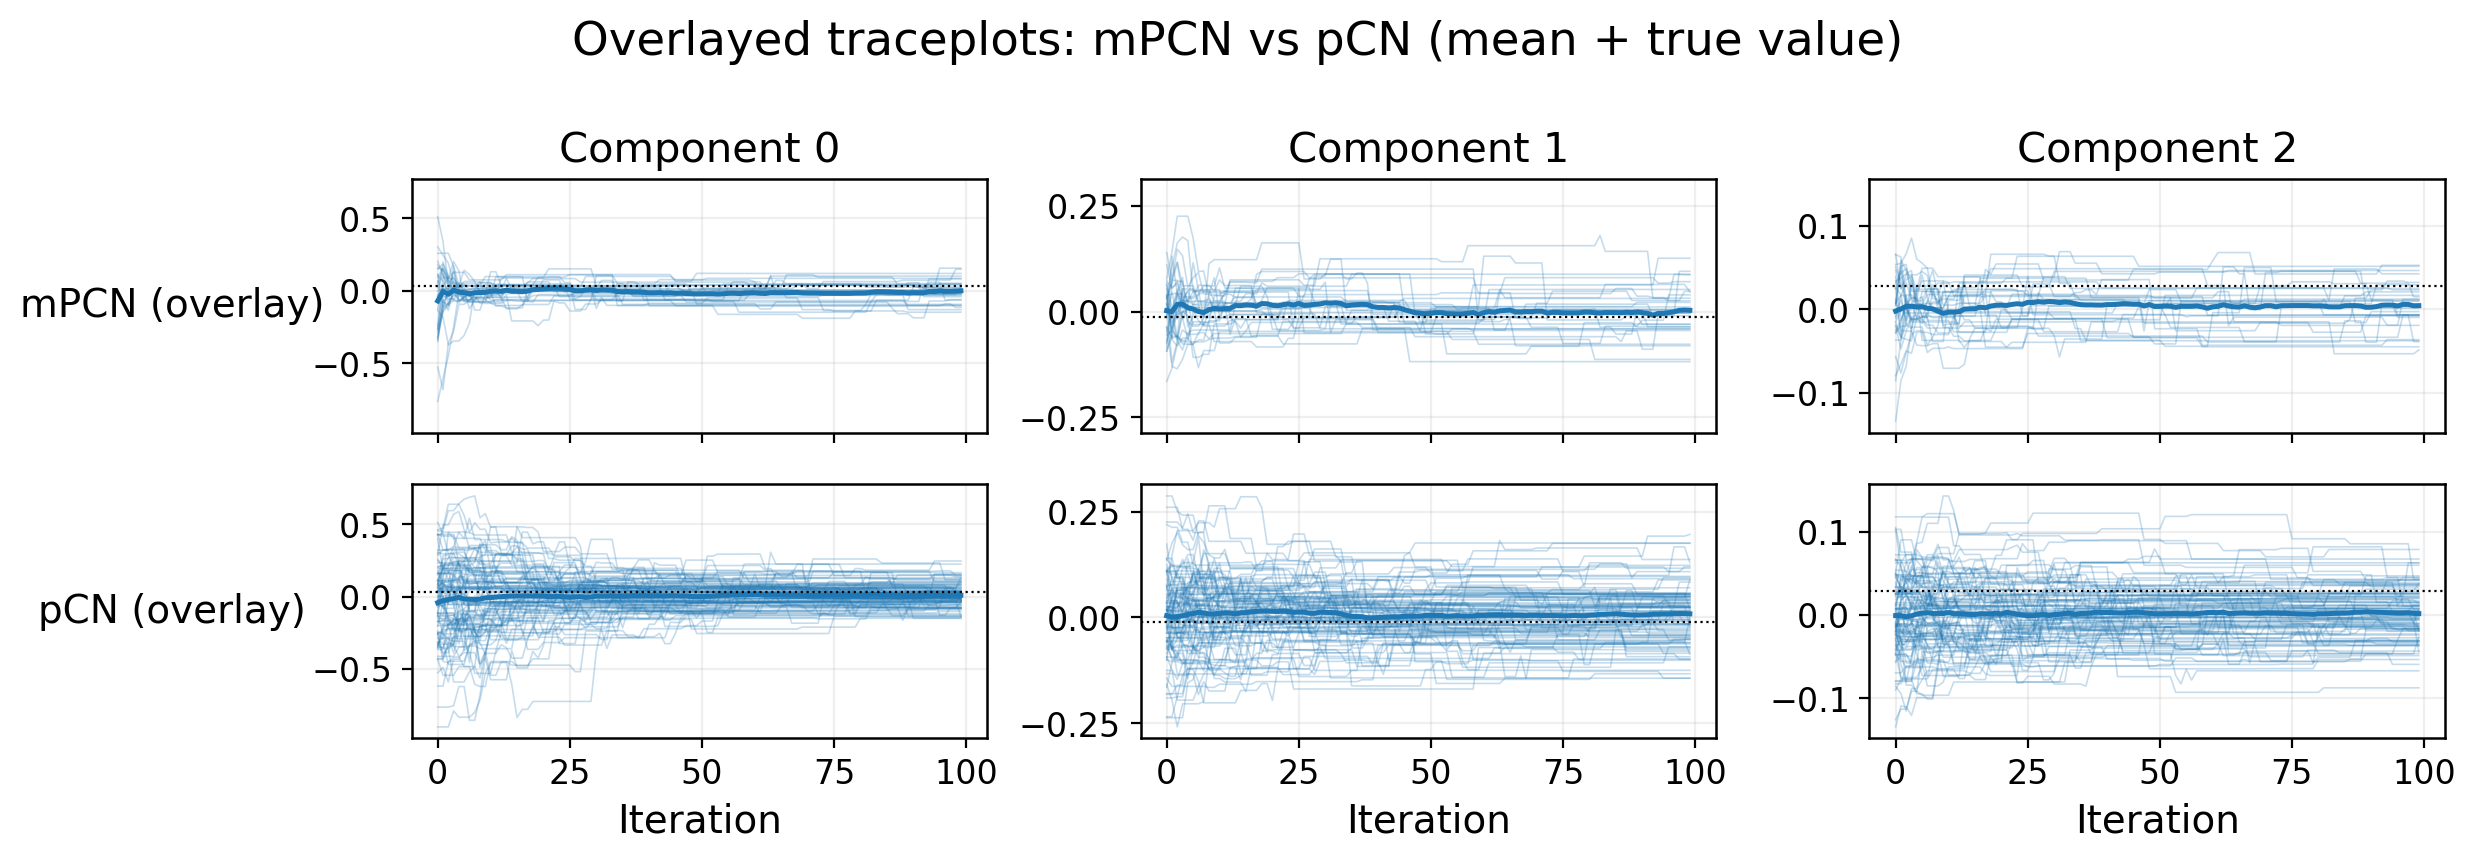

In [15]:
# Overlayed traceplots: all mPCN together and all pCN together
apply_pub_style()

comp_list = [0, 1, 2]
comp_list = [idx for idx in comp_list if idx < problem.dim]
if len(comp_list) < 1:
    raise ValueError('Need at least one component for traceplots.')

plot_n = min(n_iters, 100)
mpcn_plot_count = 30
pcn_plot_count = 100
mpcn_plot_count = min(mpcn_plot_count, len(mpcn_chains))
pcn_plot_count = min(pcn_plot_count, len(pcn_chains))

mpcn_plot_indices = list(range(mpcn_plot_count))
pcn_pick_indices = list(mpcn_start_indices)[:pcn_plot_count]
if len(pcn_pick_indices) < pcn_plot_count:
    pcn_pick_indices = list(range(pcn_plot_count))

true_values = data.get('a_true', None)

mpcn_stack = np.stack([mpcn_chains[i][:plot_n] for i in mpcn_plot_indices], axis=0)
pcn_stack = np.stack([pcn_chains[i][:plot_n] for i in pcn_pick_indices], axis=0)
mpcn_mean = np.mean(mpcn_stack, axis=0)
pcn_mean = np.mean(pcn_stack, axis=0)

nrows = 2
ncols = len(comp_list)
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4.2 * ncols, 2.2 * nrows),
    sharex=True,
    sharey='col',
)
if ncols == 1:
    axes = axes[:, None]

row_defs = [
    ('mPCN (overlay)', mpcn_stack, mpcn_mean),
    ('pCN (overlay)', pcn_stack, pcn_mean),
 ]

for row_idx, (label, stack, mean_chain) in enumerate(row_defs):
    for col_idx, comp in enumerate(comp_list):
        ax = axes[row_idx, col_idx]
        for chain_idx in range(stack.shape[0]):
            ax.plot(stack[chain_idx, :, comp], linewidth=0.6, color='tab:blue', alpha=0.25)
        ax.plot(mean_chain[:, comp], linewidth=1.8, color='tab:blue')
        if true_values is not None:
            ax.axhline(
                true_values[comp],
                color='black',
                linestyle=':',
                linewidth=0.8,
            )
        if row_idx == 0:
            ax.set_title(f'Component {comp}')
        if col_idx == 0:
            ax.set_ylabel(label, rotation=0, labelpad=50, va='center')
        ax.grid(alpha=0.2)

for ax in axes[-1, :]:
    ax.set_xlabel('Iteration')

fig.suptitle('Overlayed traceplots: mPCN vs pCN (mean + true value)')
fig.tight_layout()
fig.savefig(
    reports_dir / f'solute_transport_mpcn_vs_pcn_traceplots_overlay_rho{rho_tag}.png',
    bbox_inches='tight',
)
plt.show()